
Analyzing at time t = 75 (Year 1970)
Expected values at t = 75:
  I(t) = 3965834.29, S(t) = 38992337.46
  m_si = 9.83, p_o = 0.7024
Found 25 fixed point(s) at t = 75


/tmp/ipykernel_16275/2038528230.py:134: RuntimeWarning: invalid value encountered in power
  return s_o * (x_o**a) * (1 - x_o) - s_l * ((1 - x_o)**a) * x_o


  Fixed Point 1: (x_o = 0.6574, I = 3767542.5783) - Unstable
    S = 37042721, p = 0.7024
    Eigenvalues: [-0.05588078  0.0091683 ]
  Fixed Point 2: (x_o = 0.6644, I = 3767542.5783) - Unstable
    S = 38017529, p = 0.7158
    Eigenvalues: [-0.05648622  0.0091683 ]
  Fixed Point 3: (x_o = 0.6717, I = 3767542.5783) - Unstable
    S = 38992337, p = 0.7287
    Eigenvalues: [-0.05711688  0.0091683 ]
  Fixed Point 4: (x_o = 0.6792, I = 3767542.5783) - Unstable
    S = 39967146, p = 0.7412
    Eigenvalues: [-0.05776921  0.0091683 ]
  Fixed Point 5: (x_o = 0.6869, I = 3767542.5783) - Unstable
    S = 40941954, p = 0.7533
    Eigenvalues: [-0.05843973  0.0091683 ]
  Fixed Point 6: (x_o = 0.6532, I = 3866688.4356) - Unstable
    S = 37042721, p = 0.6890
    Eigenvalues: [-0.05534155  0.00883062]
  Fixed Point 7: (x_o = 0.6596, I = 3866688.4356) - Unstable
    S = 38017529, p = 0.7024
    Eigenvalues: [-0.05589866  0.00883062]
  Fixed Point 8: (x_o = 0.6663, I = 3866688.4356) - Unstable
    S = 

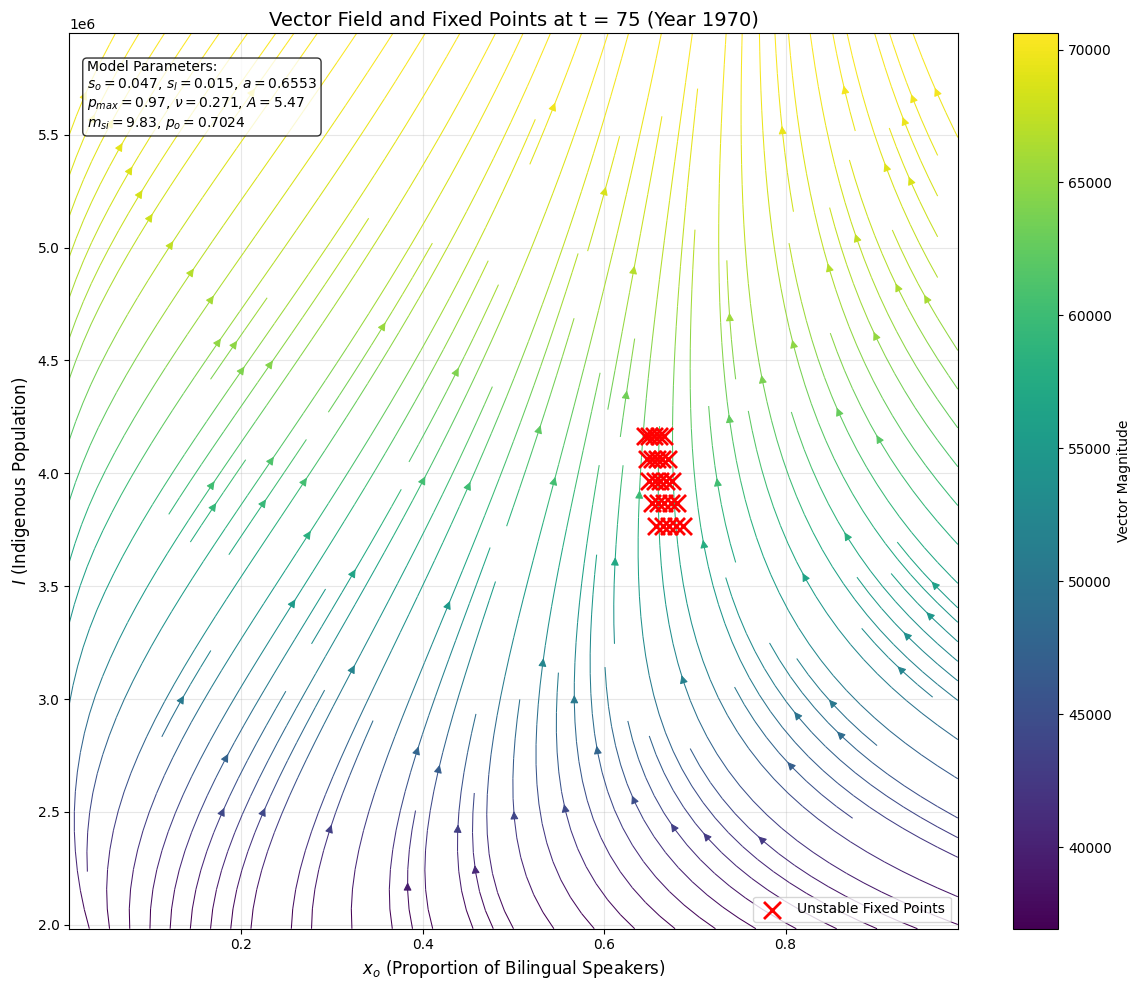

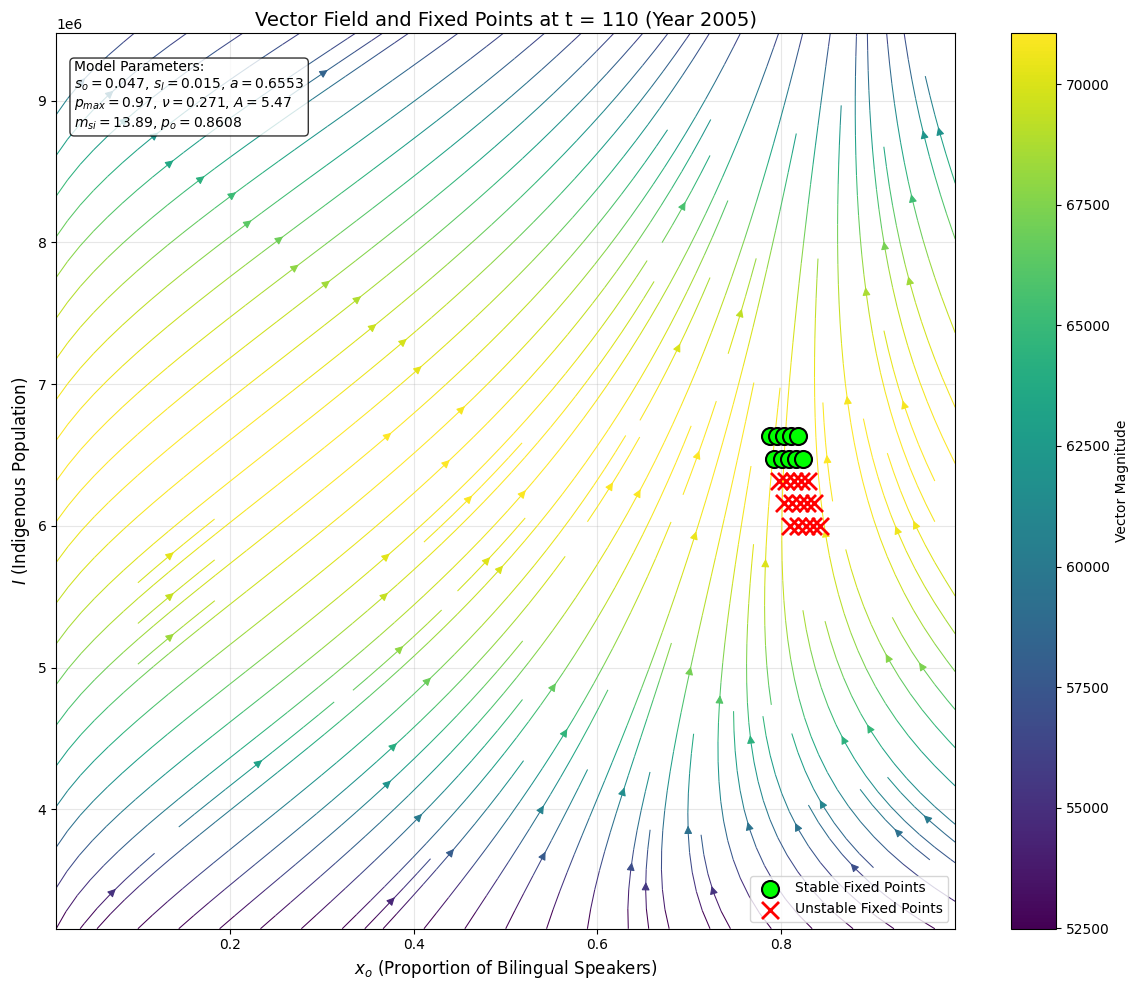

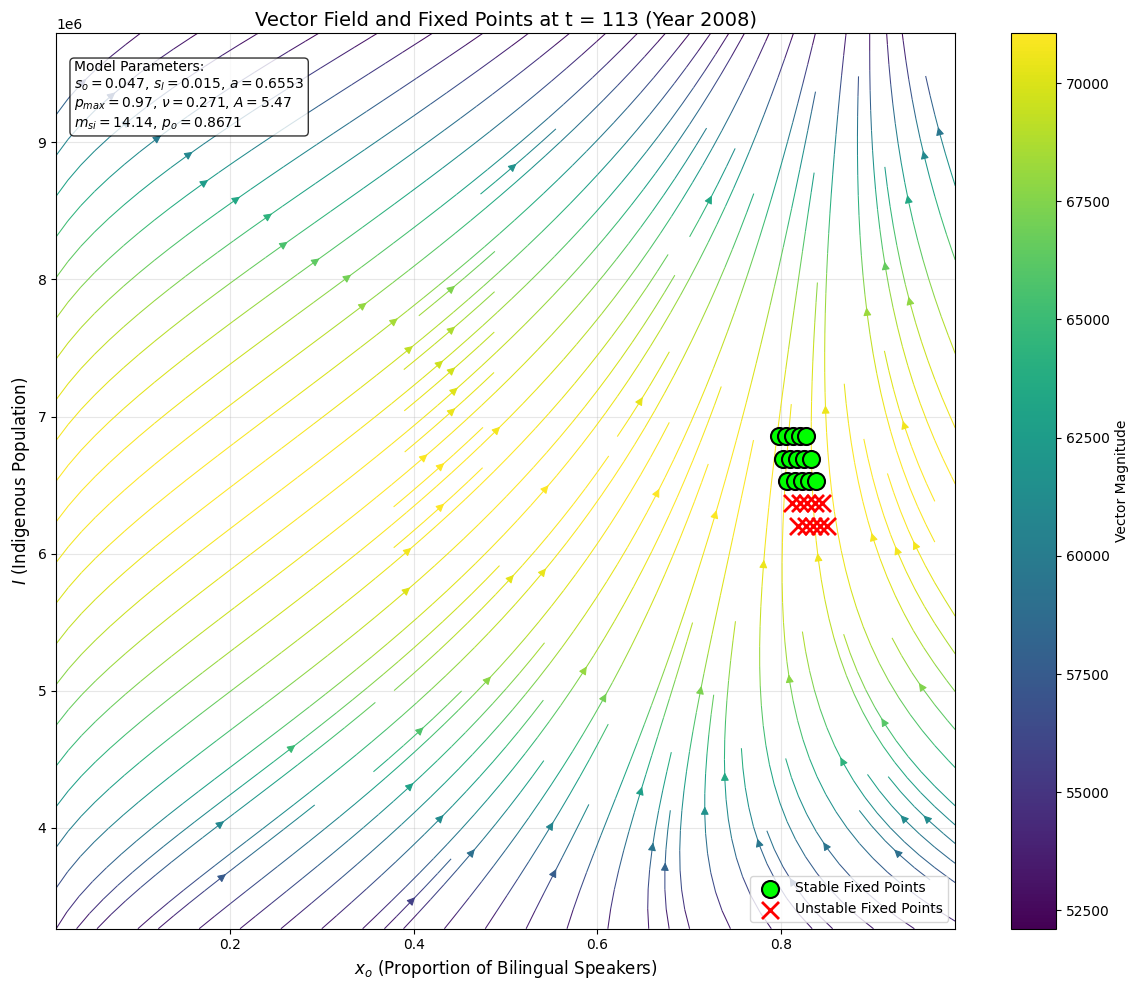

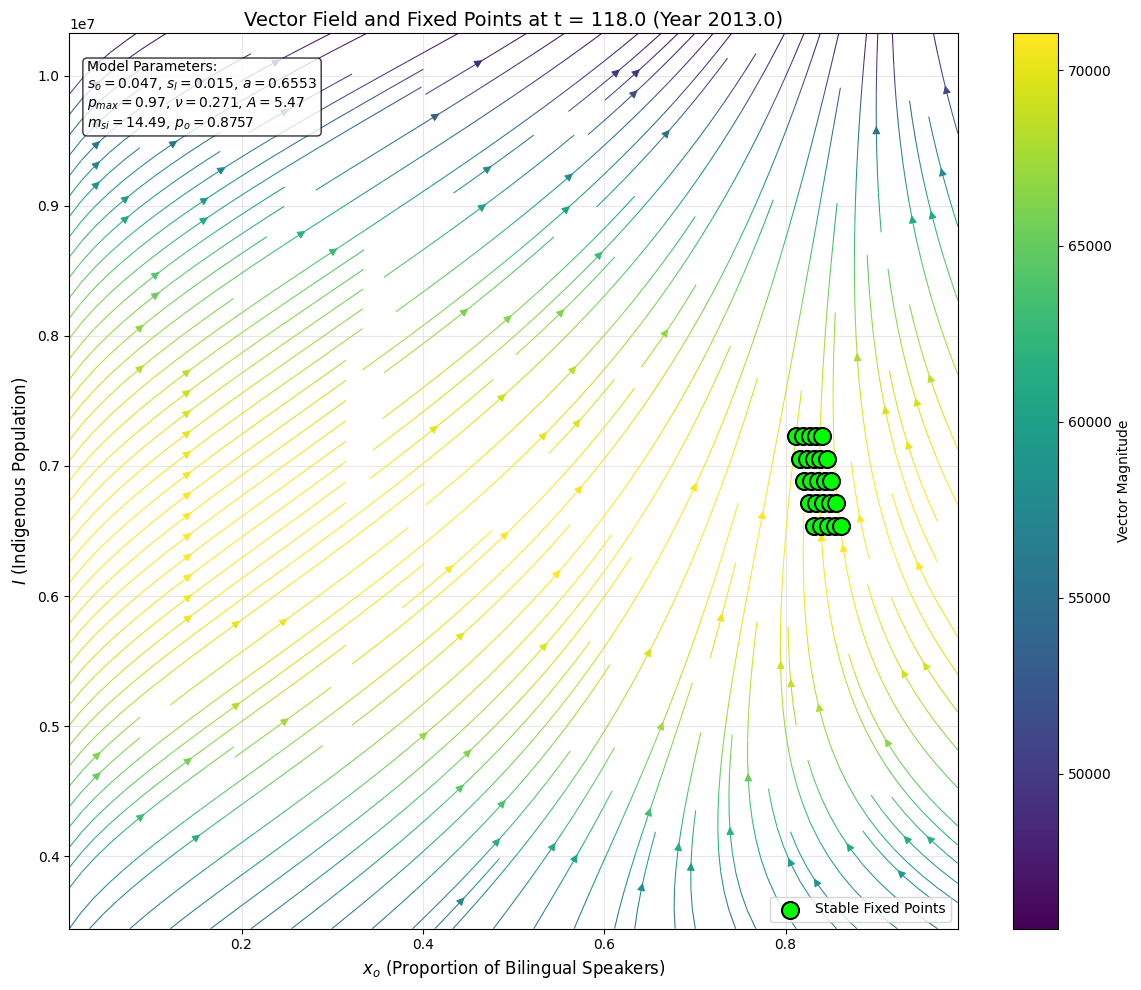

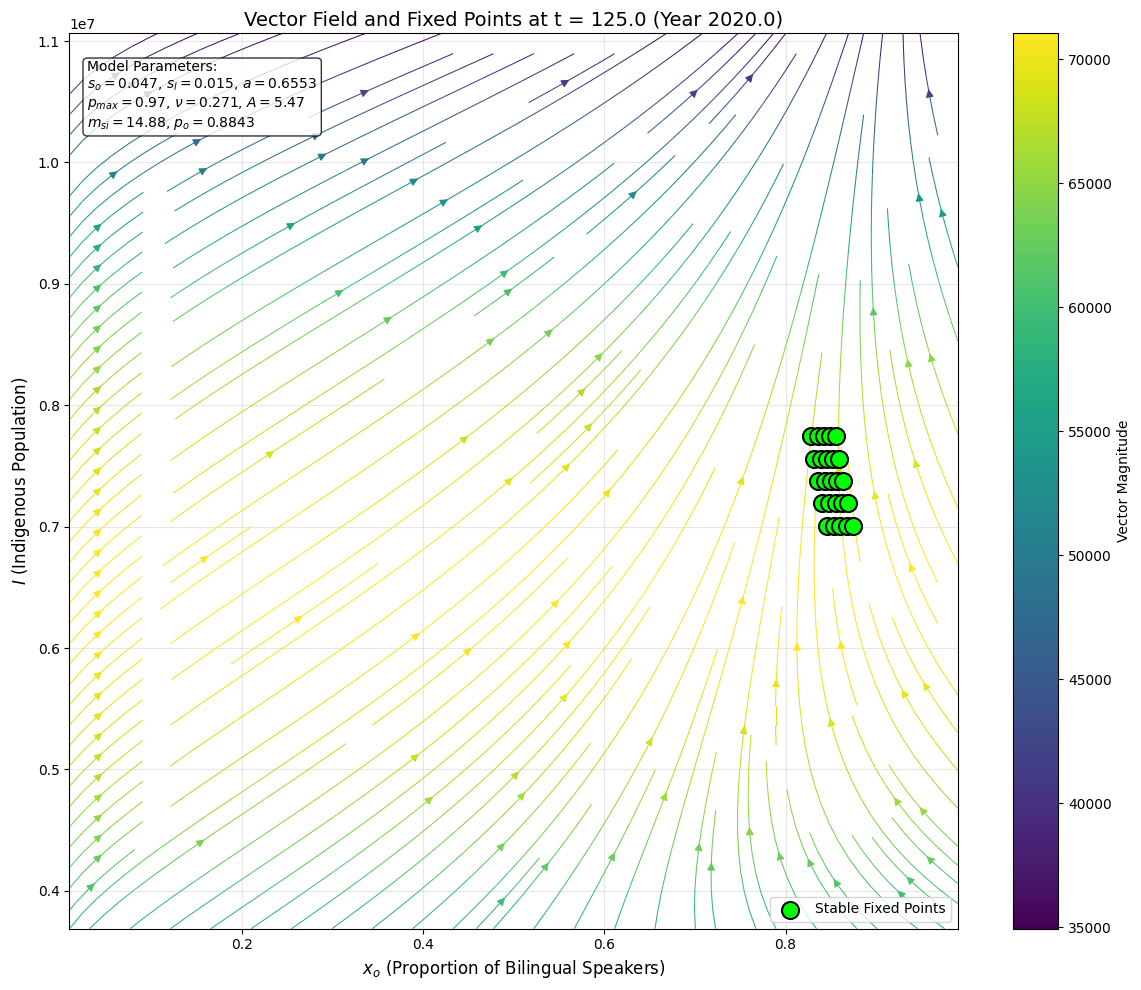

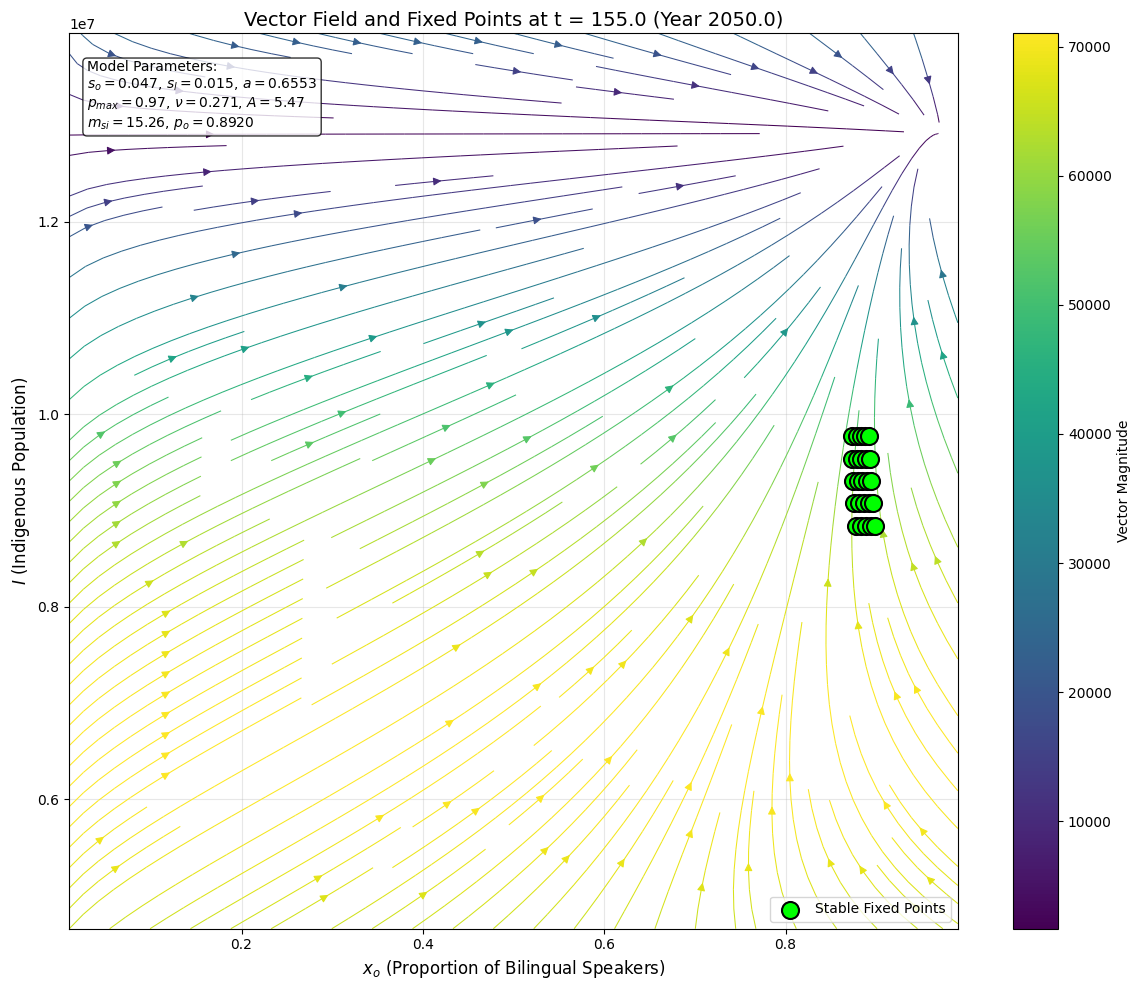

In [2]:
"""
Original script by October 2025
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.cm as cm
import matplotlib.colors as colors

# Data and parameters
data = {
    'Year': [1895, 1900, 1910, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 1995, 2000, 2005, 2010, 2020],
    'Spanish': [3394259.0, 4054539.0, 10907376.0, 11624643.0, 14080954.0, 19272593.0, 25968301.0, 36946313.0, 51353211.0, 64104668.0, 74378670.0, 78381411.0, 83704299.0, 93203961.0, 108408500.0],
    'Indigenous': [1030670.0, 1144766.0, 1619825.0, 2370324.0, 2490909.0, 2447615.0, 3030254.0, 3111415.0, 5181038.0, 5282347.0, 5483555.0, 6044547.0, 6011202.0, 6695228.0, 7177185.0],
    'Bilingual': [297977.0, 337528.0, 478232.0, 1126925.0, 1253891.0, 1652544.0, 1925299.0, 2251561.0, 3932514.0, 4411818.0, 4671553.0, 5022373.0, 5274418.0, 5676791.0, 6383553.0]
}
df = pd.DataFrame(data)

# Convert years to time points starting from 0 (1895 = 0)
base_year = 1895
df['t'] = df['Year'] - base_year

# Parameters for logistic functions
# For Bilingual
N0_bilingual = 272030  # Initial value
K_bilingual = 8615939  # Carrying capacity
r_bilingual = 0.036    # Growth rate

# For Indigenous
N0_indigenous = 1012848  # Initial value
K_indigenous = 12918933  # Carrying capacity
r_indigenous = 0.022     # Growth rate

# For Spanish
N0_spanish = 3117878    # Initial value
K_spanish = 165995301   # Carrying capacity
r_spanish = 0.037       # Growth rate

# Parameters for p_o function
A = 5.47
nu = 0.271
p_max = 0.97

# Parameters for dynamics f function
s_o = 0.0349  # Status of Bilingual language
s_l = 0.0055  # Status of Indigenous language
a = 1.252    # Preference parameter


# Parameters for dynamics f function
s_o = 0.047  # Status of Bilingual language (adjust as needed)
s_l = 0.015  # Status of Indigenous language (adjust as needed)
a = 0.6553     # Preference parameter (adjust as needed)
# Parameters to extract points of I and S around t_fixed
"""
# Parameters for dynamics f function
s_o = 0.0454  # Status of Bilingual language
s_l = 0.00838  # Status of Indigenous language
a = 1.4778    # Preference parameter
"""
delta_factor = 0.05  # 5%
num_points = 5  # five points

# Create time points for smooth curves
t_smooth = np.linspace(0, 2020-base_year, 500)

def logistic_function(t, K, r, N0):
    """
    Logistic growth function
    
    Parameters:
    t (array-like): Time points
    K (float): Carrying capacity
    r (float): Growth rate
    N0 (float): Initial value
    
    Returns:
    array-like: Population values at time t
    """
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

def m_si(t=None, S=None, I=None):
    """
    Calculate the ratio of Spanish speakers to Indigenous speakers
    
    Parameters:
    t (float or array, optional): Time points
    S (float or array, optional): Number of Spanish speakers. If None, calculated from logistic function
    I (float or array, optional): Number of Indigenous speakers. If None, calculated from logistic function
    
    Returns:
    float or array: Ratio S/I
    """
    if S is None and t is not None:
        S = logistic_function(t, K_spanish, r_spanish, N0_spanish)
    if I is None and t is not None:
        I = logistic_function(t, K_indigenous, r_indigenous, N0_indigenous)
    
    # Avoid division by zero
    if np.isscalar(I):
        return S / I if I > 0 else np.inf
    else:
        return np.where(I > 0, S / I, np.inf)

def p_o(m, p_max=p_max, A=A, nu=nu):
    """
    Calculate p_o given m_si
    
    Parameters:
    m (float or array): m_si ratio
    p_max (float): Maximum value for p_o
    A (float): Scaling parameter
    nu (float): Growth parameter
    
    Returns:
    float or array: p_o value(s)
    """
    return p_max / (1 + A * np.exp(-nu * m))

def f(x_o, s_o=s_o, s_l=s_l, a=a):
    """
    Standard dynamics term f(x_o)
    
    Parameters:
    x_o (float): Proportion of bilingual speakers
    s_o (float): Status of bilingual language
    s_l (float): Status of indigenous language
    a (float): Preference parameter
    
    Returns:
    float: Dynamics value
    """
    return s_o * (x_o**a) * (1 - x_o) - s_l * ((1 - x_o)**a) * x_o

def g(x_o, p_o, m, I):
    """
    Dynamics for natural increments
    
    Parameters:
    x_o (float): Proportion of bilingual speakers
    p_o (float): Probability parameter
    m (float): m_si ratio
    I (float): Indigenous population
    
    Returns:
    float: g function value
    """
    term_1 = p_o - x_o - p_o * (1 - p_o/p_max) * nu * m
    term_2 = r_indigenous * (1 - I/K_indigenous)
    return term_1 * term_2

def find_fixed_points(t):
    """
    Find fixed points in the system at time t
    
    Parameters:
    t (float): Time point
    
    Returns:
    list: List of fixed points (x_o, I, S, p)
    """
    fixed_points = []
    
    # Compute I(t) and S(t) from logistic function
    I_t = logistic_function(t, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic_function(t, K_spanish, r_spanish, N0_spanish)
    
    # Define ranges around I_t and S_t
    delta_I = delta_factor * I_t
    delta_S = delta_factor * S_t
    I_values = np.linspace(I_t - delta_I, I_t + delta_I, num_points)
    S_values = np.linspace(S_t - delta_S, S_t + delta_S, num_points)
    
    for i, I in enumerate(I_values):
        if I <= 0:  # Skip non-positive values
            continue
            
        for j, S in enumerate(S_values):
            m = m_si(None, S, I)
            p = p_o(m)
            
            # Define equation for fixed point
            def fixed_point_eq(x_o):
                return f(x_o) + g(x_o, p, m, I)
            
            # Try multiple initial guesses - IMPROVED to search near both 0 and 1
            initial_guesses = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
            for guess in initial_guesses:
                try:
                    sol = fsolve(fixed_point_eq, guess, full_output=True)
                    if sol[2] == 1:  # Check if fsolve converged
                        x_o = sol[0][0]
                        if 0 <= x_o <= 1:  # Check if solution is in valid range
                            fixed_points.append((x_o, I, S, p))
                except Exception as e:
                    print(f"Error in fsolve: {e}")
                    continue
    
    # Remove duplicates (with some tolerance)
    unique_points = []
    for point in fixed_points:
        is_duplicate = False
        for unique in unique_points:
            if np.abs(point[0] - unique[0]) < 1e-6 and np.abs(point[1] - unique[1]) < 1e-6:
                is_duplicate = True
                break
        if not is_duplicate:
            unique_points.append(point)
            
    return unique_points

def calculate_jacobian(x_o, I, S, p):
    """
    Calculate the Jacobian matrix at a fixed point - CORRECTED formulas for ASM model
    
    Parameters:
    x_o (float): Fixed point x_o value
    I (float): Fixed point I value
    S (float): S value at fixed point
    p (float): p value at fixed point
    
    Returns:
    numpy.ndarray: 2x2 Jacobian matrix
    """
    try:
        # Safe computations for powers
        def safe_pow(base, exponent):
            if base < 0 and not exponent.is_integer():
                return 0  # Avoid complex numbers
            if base == 0 and exponent < 0:
                return 0  # Avoid division by zero
            return base ** exponent
        
        # J_00 calculation - derivative of dx_o/dt with respect to x_o
        # Term from f(x_o)
        term1 = s_o * a * safe_pow(x_o, a-1) * (1-x_o) - s_o * safe_pow(x_o, a)
        term2 = -s_l * a * safe_pow(1-x_o, a-1) * x_o - s_l * safe_pow(1-x_o, a)
        
        # Term from g(x_o)
        term3 = -r_indigenous * (1 - I/K_indigenous)
        
        J_00 = term1 + term2 + term3
        
        # J_10 - derivative of dI/dt with respect to x_o
        J_10 = 0  # x_o doesn't affect I directly
        
        # J_01 - derivative of dx_o/dt with respect to I
        m = m_si(None, S, I)
        
        # Term from g(x_o)
        term4 = (p - x_o - p * (1 - p/p_max) * nu * m) * (-r_indigenous/K_indigenous)
        term5 = p * (1 - p/p_max) * nu * (-S/I**2) * r_indigenous * (1 - I/K_indigenous)
        
        J_01 = term4 + term5
        
        # J_11 - derivative of dI/dt with respect to I
        J_11 = r_indigenous * (1 - 2*I/K_indigenous)
        
        return np.array([[J_00, J_01], [J_10, J_11]])
    except Exception as e:
        print(f"Error calculating Jacobian: {e}")
        # Return a default Jacobian
        return np.array([[0.0, 0.0], [0.0, 0.0]])

def analyze_stability(fixed_points):
    """
    Analyze the stability of fixed points
    
    Parameters:
    fixed_points (list): List of fixed points (x_o, I, S, p)
    
    Returns:
    list: List of fixed points with stability information
    """
    results = []
    for x_o, I, S, p in fixed_points:
        try:
            J = calculate_jacobian(x_o, I, S, p)
            eigenvalues = np.linalg.eigvals(J)
            stable = all(np.real(eigenvalues) < 0)
            results.append((x_o, I, S, p, stable, eigenvalues))
        except Exception as e:
            print(f"Error in stability analysis: {e}")
            # Mark as unstable by default
            results.append((x_o, I, S, p, False, np.array([1.0, 1.0])))
    
    return results

def system(t, state, S, p):
    """
    System of differential equations
    
    Parameters:
    t (float): Time
    state (list): [x_o, I]
    S (float): Spanish speakers
    p (float): Probability parameter
    
    Returns:
    list: [dx_o/dt, dI/dt]
    """
    x_o, I = state
    
    if I <= 0:  # Avoid division by zero
        return [0, 0]
    
    m = m_si(None, S, I)
    
    # dx_o/dt calculation
    term_1 = f(x_o)  # Standard dynamics
    term_2 = g(x_o, p, m, I)  # Natural increments
    dx_o_dt = term_1 + term_2
    
    # dI/dt calculation
    dI_dt = r_indigenous * I * (1 - (I/K_indigenous))
    
    return [dx_o_dt, dI_dt]

def plot_vector_field(t, x_range, I_range, S, p, fixed_points_with_stability):
    """
    Plot vector field and fixed points - IMPROVED visualization
    
    Parameters:
    t (float): Time
    x_range (array): Range of x_o values
    I_range (array): Range of I values
    S (float): Spanish speakers at time t
    p (float): Probability parameter at time t
    fixed_points_with_stability (list): Fixed points with stability information
    
    Returns:
    matplotlib.figure.Figure: Figure object
    """
    X, I = np.meshgrid(x_range, I_range)
    U = np.zeros(X.shape)
    V = np.zeros(X.shape)
    
    # Calculate derivatives at each grid point
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            if I[i, j] > 0:
                derivatives = system(t, [X[i, j], I[i, j]], S, p)
                U[i, j], V[i, j] = derivatives

    # Compute magnitude for color mapping
    magnitude = np.sqrt(U**2 + V**2)
    # Avoid division by zero in normalization
    max_mag = np.percentile(magnitude[magnitude > 0], 95) if np.any(magnitude > 0) else 1.0
    U_norm = np.where(magnitude > 0, U / max_mag, 0)
    V_norm = np.where(magnitude > 0, V / max_mag, 0)

    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use streamplot with normalized vectors
    stream = ax.streamplot(X, I, U_norm, V_norm, density=1.5, color=magnitude, 
                           cmap='viridis', linewidth=0.75, arrowsize=1.2)

    # Plot fixed points with larger markers
    stable_points = [(x, I) for x, I, _, _, stable, _ in fixed_points_with_stability if stable]
    unstable_points = [(x, I) for x, I, _, _, stable, _ in fixed_points_with_stability if not stable]

    if stable_points:
        stable_x, stable_I = zip(*stable_points)
        ax.scatter(stable_x, stable_I, color='lime', s=150, marker='o', 
                  edgecolor='black', linewidth=1.5, label='Stable Fixed Points', zorder=3)

    if unstable_points:
        unstable_x, unstable_I = zip(*unstable_points)
        ax.scatter(unstable_x, unstable_I, color='red', s=150, marker='x', 
                  linewidth=2, label='Unstable Fixed Points', zorder=3)

    # Add additional information to the plot
    ax.set_xlabel('$x_o$ (Proportion of Bilingual Speakers)', fontsize=12)
    ax.set_ylabel('$I$ (Indigenous Population)', fontsize=12)
    ax.set_title(f'Vector Field and Fixed Points at t = {t} (Year {base_year + t})', fontsize=14)
    
    # Display model parameters
    params_text = (
        f"Model Parameters:\n"
        f"$s_o = {s_o}$, $s_l = {s_l}$, $a = {a}$\n"
        f"$p_{{max}} = {p_max}$, $\\nu = {nu}$, $A = {A}$\n"
        f"$m_{{si}} = {m_si(None, S, I_range.mean()):.2f}$, $p_o = {p:.4f}$"
    )
    ax.text(0.02, 0.97, params_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlim(min(x_range), max(x_range))
    ax.set_ylim(min(I_range), max(I_range))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=10)

    # Correct colorbar handling
    norm = colors.Normalize(vmin=magnitude.min(), vmax=magnitude.max())
    sm = cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])  # Required for colorbar
    cbar = fig.colorbar(sm, ax=ax, label='Vector Magnitude')

    plt.tight_layout()
    return fig

def analyze_system(time_points):
    """
    Analyze system dynamics at specified time points
    
    Parameters:
    time_points (list): List of time points to analyze
    
    Returns:
    dict: Dictionary of results for each time point
    """
    all_results = {}
    
    for t in time_points:
        print(f"\nAnalyzing at time t = {t} (Year {base_year + t})")
        
        # Calculate the expected values of I and S at time t
        I_t = logistic_function(t, K_indigenous, r_indigenous, N0_indigenous)
        S_t = logistic_function(t, K_spanish, r_spanish, N0_spanish)
        m_t = m_si(None, S_t, I_t)
        p_t = p_o(m_t)
        
        print(f"Expected values at t = {t}:")
        print(f"  I(t) = {I_t:.2f}, S(t) = {S_t:.2f}")
        print(f"  m_si = {m_t:.2f}, p_o = {p_t:.4f}")
        
        # Find fixed points
        fixed_points = find_fixed_points(t)
        print(f"Found {len(fixed_points)} fixed point(s) at t = {t}")
        
        # Analyze stability
        stability_results = analyze_stability(fixed_points)
        
        # Print fixed points and stability
        x_o_list=[]
        eigen_list=[]
        
        for i, (x_o, I, S, p, stable, eigenvalues) in enumerate(stability_results):
            stability = "Stable" if stable else "Unstable"
            print(f"  Fixed Point {i+1}: (x_o = {x_o:.4f}, I = {I:.4f}) - {stability}")
            print(f"    S = {S:.0f}, p = {p:.4f}")
            print(f"    Eigenvalues: {eigenvalues}")
            x_o_list.append(x_o)
            eigen_list.append(eigenvalues[0])
        

        # Mean x_o for stable vs unstable fixed points
        stable_x_o = [x_o for x_o, _, _, _, stable, _ in stability_results if stable]
        unstable_x_o = [x_o for x_o, _, _, _, stable, _ in stability_results if not stable]
        
        if stable_x_o:
            mean_stable_x_o = np.mean(stable_x_o)
            print(f"Mean x_o for stable fixed points: {mean_stable_x_o:.4f}")
        
        if unstable_x_o:
            mean_unstable_x_o = np.mean(unstable_x_o)
            print(f"Mean x_o for unstable fixed points: {mean_unstable_x_o:.4f}")
        # Option 3: Mean of dominant eigenvalues (the one with largest real part from each fixed point)
        dominant_eigenvalues = []
        for _, _, _, _, _, eigenvalues in stability_results:
            # Find eigenvalue with largest real part
            dominant = max(eigenvalues, key=lambda x: np.real(x))
            dominant_eigenvalues.append(dominant)
        mean_dominant = np.mean(dominant_eigenvalues)
        print(f"Mean of the dominant eigenvalue: {mean_dominant:.4f}")

        dominant_eigenvalues = []
        for _, _, _, _, _, eigenvalues in stability_results:
            # Find eigenvalue with largest magnitude (absolute value)
            dominant = max(eigenvalues, key=lambda x: abs(x))
            dominant_eigenvalues.append(dominant)
        mean_dominant_magnitude = np.mean([abs(eig) for eig in dominant_eigenvalues])
        print(f"Mean of the dominant ABS eigenvalue: {mean_dominant_magnitude:.4f}")
        x_range = np.linspace(0.01, 0.99, 30)
        
        # Use a reasonable range around the expected I_t
        I_min = max(0.1, I_t * 0.5)
        I_max = I_t * 1.5
        I_range = np.linspace(I_min, I_max, 30)
        
        # Create vector field plot using expected trajectory values
        fig = plot_vector_field(t, x_range, I_range, S_t, p_t, stability_results)
        
        all_results[t] = {
            'fixed_points': fixed_points,
            'stability': stability_results,
            'figure': fig,
            'I_t': I_t,
            'S_t': S_t,
            'm_t': m_t,
            'p_t': p_t
        }
    
    return all_results

def main():
    # Define analysis parameters - years since 1895
    time_points = [75.0, 85.0, 95.0, 105.0, 115.0,118.0]
    time_points = [75,110,113,118.0,125.0,155.0]
    #time_points = [780, 800, 820, 850, 900,1000]
    #time_points = [10.0, 40.0, 60.0, 75.0]
    
    # Run the analysis
    results = analyze_system(time_points)
    
    # Save figures
    for t, result in results.items():
        result['figure'].savefig(f"vector_field_t{int(t)}.png", dpi=300, bbox_inches='tight')
    
    plt.show()

if __name__ == "__main__":
    main()